In [6]:
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import (
                                    StratifiedKFold, 
                                    cross_validate,
                                    train_test_split
                                    )
from sklearn.metrics import (
                            confusion_matrix,
                            f1_score,
                            accuracy_score,
                            precision_score,
                            recall_score
                            )
warnings.filterwarnings('ignore')

### 1. Load the data

In [7]:
from pathlib import Path

project_root = Path.cwd()
for parent in [project_root, *project_root.parents]:
    if (parent / 'artifacts').exists():
        project_root = parent
        break

with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_train.npz') as data:
    X_train = data['X_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_train.npz') as data:
    Y_train = data['y_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_test.npz') as data:
    X_test = data['X_test']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_test.npz') as data:
    Y_test = data['y_test']

### 2. Define Multi Models

In [8]:
models = {
        'Logistic Regression' : LogisticRegression(C=0.01, max_iter=1000, random_state=42),
        'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
        'Random Forest' : RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42),
        'XGBoost' : XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='logloss')
        }

### 3. Configure K-Fold CV

In [9]:
cv = StratifiedKFold(
                    n_splits=6,
                    random_state=42,
                    shuffle=True
                    )

In [10]:
from imblearn.over_sampling import SMOTENC

# Load the original scaled dataset to perform threshold search on imbalanced validation folds
df_orig = pd.read_csv(project_root / 'dataset' / 'processed' / 'credit_card_fraud_scaled.csv')
if 'transaction_id' in df_orig.columns:
    df_orig = df_orig.drop(columns=['transaction_id'])

X_orig = df_orig.drop(columns=['is_fraud'])
y_orig = df_orig['is_fraud']

# Split in exactly the same way to retrieve original training split
X_train_orig, _, y_train_orig, _ = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

# Identify categorical features for SMOTENC
CONTINUOUS_COLS = ['amount', 'transaction_hour', 'velocity_last_24h', 'cardholder_age']
categorical_cols = [col for col in X_train_orig.columns if col not in CONTINUOUS_COLS]
categorical_features = [X_train_orig.columns.get_loc(col) for col in categorical_cols]

trained_models = {}
best_thresholds = {}

for model_name, model in models.items():
    print(f"\nCross Validation & Threshold Tuning on {model_name}...")
    
    # Stratified K-Fold CV to get OOF probabilities on imbalanced validation folds
    oof_probs = np.zeros(len(X_train_orig))
    for train_idx, val_idx in cv.split(X_train_orig, y_train_orig):
        X_tr_fold, y_tr_fold = X_train_orig.iloc[train_idx], y_train_orig.iloc[train_idx]
        X_val_fold, y_val_fold = X_train_orig.iloc[val_idx], y_train_orig.iloc[val_idx]
        
        # Apply SMOTENC to training fold only
        smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
        X_tr_res, y_tr_res = smotenc.fit_resample(X_tr_fold, y_tr_fold)
        
        # Clone model and fit
        fold_model = model.__class__(**model.get_params())
        fold_model.fit(X_tr_res, y_tr_res)
        oof_probs[val_idx] = fold_model.predict_proba(X_val_fold)[:, 1]
        
    # Search for threshold maximizing OOF F1-score
    best_th = 0.5
    best_f1 = 0
    for th in np.linspace(0.01, 0.99, 99):
        y_pred_th = (oof_probs >= th).astype(int)
        f1 = f1_score(y_train_orig, y_pred_th)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
            
    best_thresholds[model_name] = best_th
    print(f"{model_name}: Optimal Threshold={best_th:.4f} (OOF F1: {best_f1:.4f})")
    
    # Train final model on full SMOTE-balanced training set from artifacts
    final_model = model.__class__(**model.get_params())
    final_model.fit(X_train, Y_train)
    trained_models[model_name] = final_model


Cross Validation & Threshold Tuning on Logistic Regression...
Logistic Regression: Optimal Threshold=0.8600 (OOF F1: 0.5344)

Cross Validation & Threshold Tuning on Decision Tree...
Decision Tree: Optimal Threshold=0.9400 (OOF F1: 0.4411)

Cross Validation & Threshold Tuning on Random Forest...
Random Forest: Optimal Threshold=0.6000 (OOF F1: 0.5826)

Cross Validation & Threshold Tuning on XGBoost...
XGBoost: Optimal Threshold=0.6700 (OOF F1: 0.6254)


In [ ]:
trained_models

In [ ]:
Y_hat_tests = {}
for model_name, model in trained_models.items():
    # Predict probabilities and apply the optimized threshold
    y_proba_test = model.predict_proba(X_test)[:, 1]
    best_th = best_thresholds[model_name]
    Y_hat_test = (y_proba_test >= best_th).astype(int)
    Y_hat_tests[model_name] = Y_hat_test
    
    print(f"\nEvaluation metrics for {model_name} (Threshold: {best_th:.2f}):")
    print(f"accuracy : {accuracy_score(Y_test, Y_hat_test):.4f}")
    print(f"precision : {precision_score(Y_test, Y_hat_test):.4f}")
    print(f"recall : {recall_score(Y_test, Y_hat_test):.4f}")
    print(f"f1_score : {f1_score(Y_test, Y_hat_test):.4f}")


Evaluation metrics for Logistic Regression (Threshold: 0.86):
accuracy : 0.9880
precision : 0.5789
recall : 0.7333
f1_score : 0.6471

Evaluation metrics for Decision Tree (Threshold: 0.94):
accuracy : 0.9880
precision : 0.5882
recall : 0.6667
f1_score : 0.6250

Evaluation metrics for Random Forest (Threshold: 0.60):
accuracy : 0.9890
precision : 0.6429
recall : 0.6000
f1_score : 0.6207

Evaluation metrics for XGBoost (Threshold: 0.77):
accuracy : 0.9875
precision : 0.5610
recall : 0.7667
f1_score : 0.6479


In [ ]:
cm1 = confusion_matrix(Y_test, Y_hat_tests['Logistic Regression'])
cm2 = confusion_matrix(Y_test, Y_hat_tests['Decision Tree'])
cm3 = confusion_matrix(Y_test, Y_hat_tests['Random Forest'])
cm4 = confusion_matrix(Y_test, Y_hat_tests['XGBoost'])

NameError: name 'confusion_matrix' is not defined

NameError: name 'cm1' is not defined

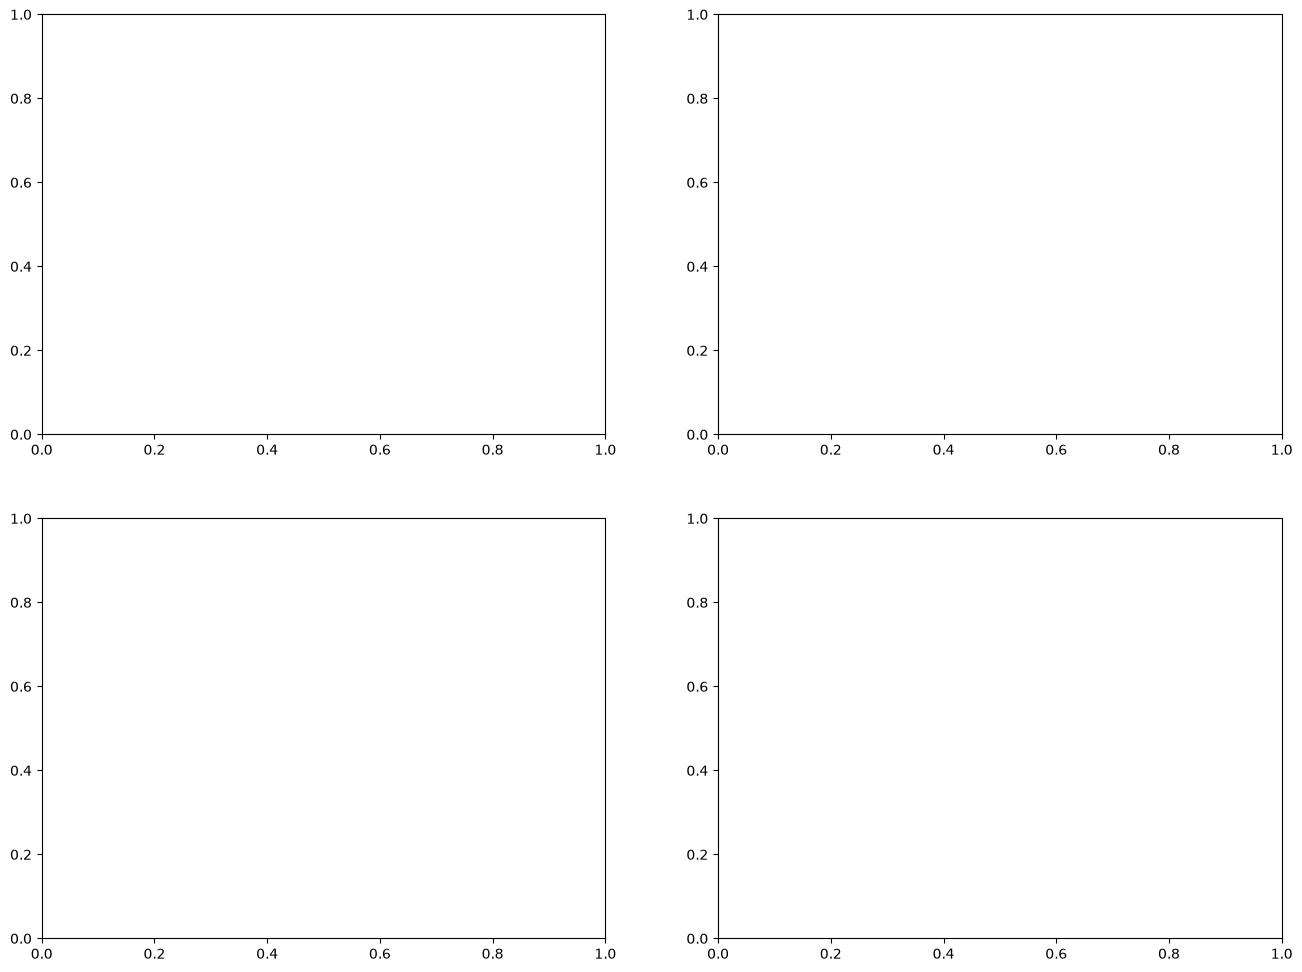

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

sns.heatmap(cm1, annot=True, fmt='d', ax=ax1)
ax1.set_title('Logistic Regression')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm2, annot=True, fmt='d', ax=ax2)
ax2.set_title('Decision Tree')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

sns.heatmap(cm3, annot=True, fmt='d', ax=ax3)
ax3.set_title('Random Forest')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

sns.heatmap(cm4, annot=True, fmt='d', ax=ax4)
ax4.set_title('XGBoost')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.tight_layout()
plt.show()